In [3]:
import datetime
import os
import ee
import geemap
import joblib
import matplotlib.pyplot as plt

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_indices
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from build_data_table import build_feature_table, export_prediction_avg_assets
from edit_data_table import edit_feature_table
from plot_feature_distributions import plot_feature_distributions
from decision_trees import split_data, fit_tree
from gridmet_utils import fetch_gridmet_cdd_historical

from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn import tree

ee.Initialize(project='turnkey-lacing-391919')

OUTPUT_DIR = './greendown_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2013  # First HLS year
download_year = 2025  # Last year to download (includes 2025 for prediction)
train_year    = 2024  # Last year included in model training

# ----------------------------
# Fit logistic curves for each year (download all years including 2025)
# ----------------------------
all_year_paths = []
for y in range(start_year, download_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_indices(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, output_dir=OUTPUT_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, output_dir=OUTPUT_DIR)

# ----------------------------
# Export committed assets the live (Action) prediction needs for
# doy_minus_avg_middle: the CI-filtered per-pixel cross-year average and the
# global gap-fill scalar. Re-run on every retrain, then commit:
#   greendown_middle_avg_filtered.tif, greendown_avg_meta.json
# ----------------------------
print('\nExporting prediction average assets...')
export_prediction_avg_assets(OUTPUT_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, download_year + 1))
count_narrow_ci_pixel_years(OUTPUT_DIR, years)

# ----------------------------
# Download gridMET cold degree-days for training years (stored locally).
# Skips any year whose gridmet_cdd_{year}.npz is already cached.
# Must be run before build_feature_table so the cdd_accumulated feature
# can be populated. Re-running is safe — cached years are skipped.
# ----------------------------
print('\nDownloading gridMET CDD for training years...')
training_years = list(range(start_year, train_year + 1))
for y in training_years:
    fetch_gridmet_cdd_historical(y, route_buffer, OUTPUT_DIR)

# ----------------------------
# Build labeled EVI/NDVI feature table (training years only: 2013–2024)
# ----------------------------
print('\nBuilding labeled feature table...')
feature_df = build_feature_table(OUTPUT_DIR, training_years)
#plot_feature_distributions(feature_df)
feature_df_edited = edit_feature_table(feature_df, OUTPUT_DIR)
print(feature_df_edited.head())
print('\nNaN counts per column:')
print(feature_df_edited.isna().sum())
#plot_feature_distributions(feature_df_edited)

Processing 2013...
  Using cached results for 2013
Processing 2014...
  Using cached results for 2014
Processing 2015...
  Using cached results for 2015
Processing 2016...
  Using cached results for 2016
Processing 2017...
  Using cached results for 2017
Processing 2018...
  Using cached results for 2018
Processing 2019...
  Using cached results for 2019
Processing 2020...
  Using cached results for 2020
Processing 2021...
  Using cached results for 2021
Processing 2022...
  Using cached results for 2022
Processing 2023...
  Using cached results for 2023
Processing 2024...
  Using cached results for 2024
Processing 2025...
  Using cached results for 2025
Computing averages...


/Users/Kathryn/Documents/Professional Development/Google Earth Engine/AppTrail_Phenology/fit_greendown_curves.py:542: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(np.stack(arrays, axis=0), axis=0).astype(np.float32)



Exporting prediction average assets...
  Wrote ./greendown_outputs/greendown_middle_avg_filtered.tif (9240 valid pixels)
  Wrote ./greendown_outputs/greendown_avg_meta.json (global_avg_middle = 278.10)

Filtering pixel-years by CI width...
  2013: 600 pixels (all phases)  |  start: 610  middle: 859  end: 606
  2014: 229 pixels (all phases)  |  start: 268  middle: 913  end: 244
  2015: 403 pixels (all phases)  |  start: 496  middle: 2290  end: 473
  2016: 282 pixels (all phases)  |  start: 288  middle: 435  end: 286
  2017: 186 pixels (all phases)  |  start: 197  middle: 621  end: 204
  2018: 920 pixels (all phases)  |  start: 932  middle: 1240  end: 925
  2019: 157 pixels (all phases)  |  start: 172  middle: 606  end: 180
  2020: 155 pixels (all phases)  |  start: 164  middle: 299  end: 164
  2021: 440 pixels (all phases)  |  start: 454  middle: 797  end: 462
  2022: 409 pixels (all phases)  |  start: 526  middle: 1420  end: 534
  2023: 500 pixels (all phases)  |  start: 697  middle: 

12
29
29
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 12, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 29, 'min_samples_split': 29, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1234, 'splitter': 'best'}
Model saved to ./greendown_outputs/decision_tree_model.joblib


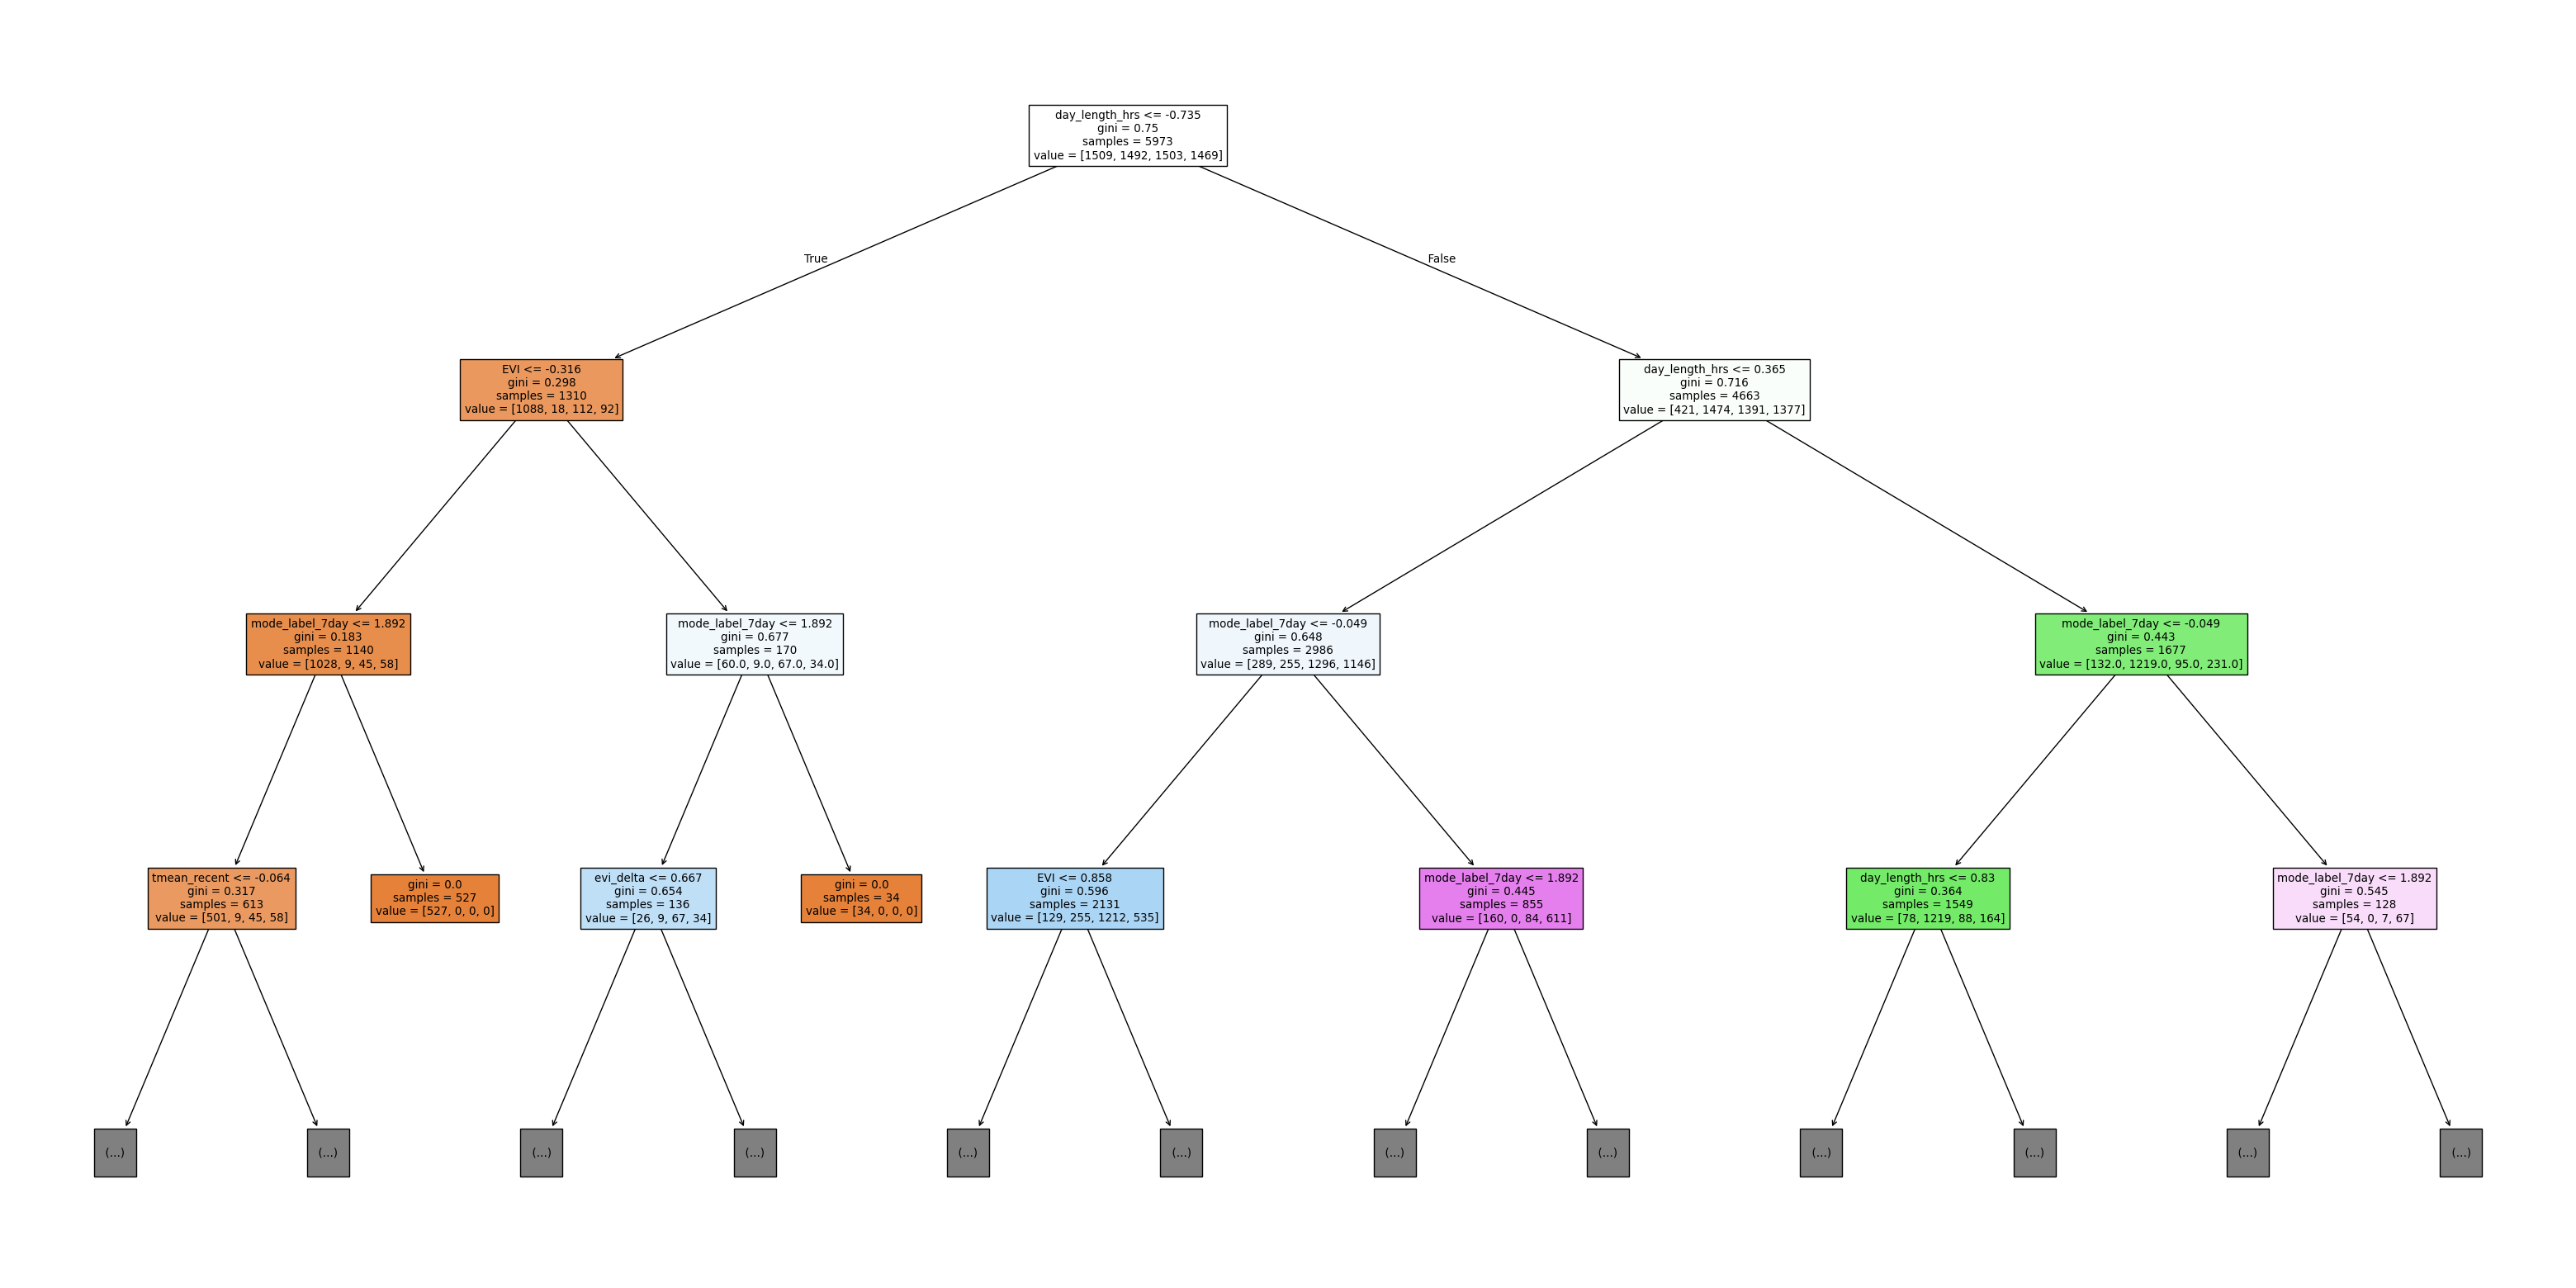

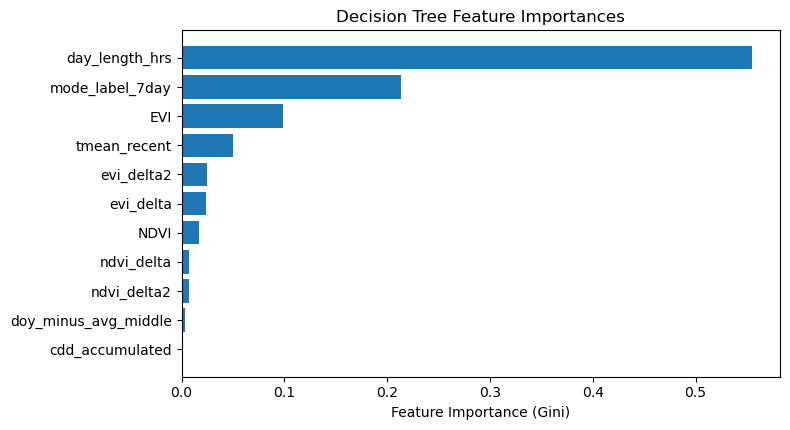


Test Accuracy Score:
0.784028126569563
              precision    recall  f1-score   support

       after       0.90      0.91      0.90       482
      before       0.82      0.88      0.85       499
       early       0.69      0.67      0.68       488
        late       0.73      0.68      0.70       522

    accuracy                           0.78      1991
   macro avg       0.78      0.79      0.78      1991
weighted avg       0.78      0.78      0.78      1991


Train Accuracy Score:
0.8076343545956806
              precision    recall  f1-score   support

       after       0.89      0.89      0.89      1509
      before       0.84      0.89      0.86      1492
       early       0.75      0.73      0.74      1503
        late       0.74      0.72      0.73      1469

    accuracy                           0.81      5973
   macro avg       0.81      0.81      0.81      5973
weighted avg       0.81      0.81      0.81      5973



In [4]:
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)

mdl = fit_tree(x_train, y_train, True)
print(mdl.get_depth())
print(mdl.min_samples_split)
print(mdl.min_samples_leaf)
print(mdl.get_params())

# Save model for dashboard use
joblib.dump(mdl, os.path.join(OUTPUT_DIR, 'decision_tree_model.joblib'))
print(f'Model saved to {OUTPUT_DIR}/decision_tree_model.joblib')

# ----------------------------
# Visualize decision tree
# ----------------------------
fig, ax = plt.subplots(figsize=(40, 20))
tree.plot_tree(mdl, feature_names=list(x_train.columns), max_depth = 3, filled=True, ax=ax)
fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()

# Plot feature importances
importances = mdl.feature_importances_
feature_names = list(x_train.columns)
sorted_idx = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.4)))
ax.barh([feature_names[i] for i in sorted_idx], [importances[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'feature_importances.png'), dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# Test on test data
# ----------------------------
y_pred = mdl.predict(x_test)

# ----------------------------
# Evaluate model
# ----------------------------
print('\nTest Accuracy Score:')
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Check for overfitting by comparing accuracy of predicting training data to predicting test data
y_pred_train = mdl.predict(x_train)
print('\nTrain Accuracy Score:')
print(accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))
#Take-away: without pruning the accuracy on the training data is 1 and the accuracy on the testing data in 0.75 so the model is overfitting
    #With pruning the test accuracy is 0.74 and training is 0.78 so much closer and less overfitting

In [4]:
from explain_prediction import explain_prediction
result = explain_prediction({"EVI": 0.5816, 
                             "NDVI": 0.8784,
                             "day_length_hrs": 15.0972 ,
                             "evi_delta": -0.0009,
                             "evi_delta2": 0.2177,
                             "NDVI_delta": 0.8784,
                             "NDVI_delta2": 0.8137,
                             "doy_minus_avg_middle": -78.2897})
print(result)

Input (raw): EVI=0.5816, NDVI=0.8784, evi_delta=-0.0009, evi_delta2=0.2177, day_length_hrs=15.0972, doy_minus_avg_middle=-78.2897
Missing (treated as training mean): ndvi_delta, ndvi_delta2

Decision path:
   1. day_length_hrs         =   15.0972  >   10.2907   -> go RIGHT
   2. day_length_hrs         =   15.0972  >   12.0365   -> go RIGHT
   3. day_length_hrs         =   15.0972  >   12.7751   -> go RIGHT
   4. NDVI                   =    0.8784  <=    0.8809   -> go LEFT
   5. NDVI                   =    0.8784  >    0.8614   -> go RIGHT
   6. day_length_hrs         =   15.0972  >   14.6795   -> go RIGHT

=> PREDICT "late"  (leaf n=31, 68% pure; before=26%, early=6%, late=68%)
{'prediction': 'late', 'steps': [{'feature': 'day_length_hrs', 'value': 15.0972, 'threshold': 10.290749468358845, 'direction': 'right (>)', 'missing': False}, {'feature': 'day_length_hrs', 'value': 15.0972, 'threshold': 12.036532829055831, 'direction': 'right (>)', 'missing': False}, {'feature': 'day_length_hrs

/opt/anaconda3/envs/gee/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/gee/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
